# RQ1 Visualization of PCA results across pandemic stages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

df = pd.read_csv('../data/df_pca.csv')
df['Week_End'] = pd.to_datetime(df['Week_End'])

pcs = ['PC1', 'PC2', 'PC3', 'PC4']
stage_order = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
stage_labels = {
    'Stage 1 (2017-2019)': 'Pre (2017-2019)',
    'Stage 2 (2020-2022)': 'Pandemic (2020-2022)',
    'Stage 3 (2023-2025)': 'Post (2023-2025)'
}
pc_labels = {
    'PC1': 'PC1: Intensity',
    'PC2': 'PC2: Vocal Style',
    'PC3': 'PC3: Instrumentalness',
    'PC4': 'PC4: Positive Vocal'
}
colors = ['#4C72B0', '#DD8452', '#55A868']

df.shape

(91709, 25)

## Figure 1: Mean PC Scores by Stage

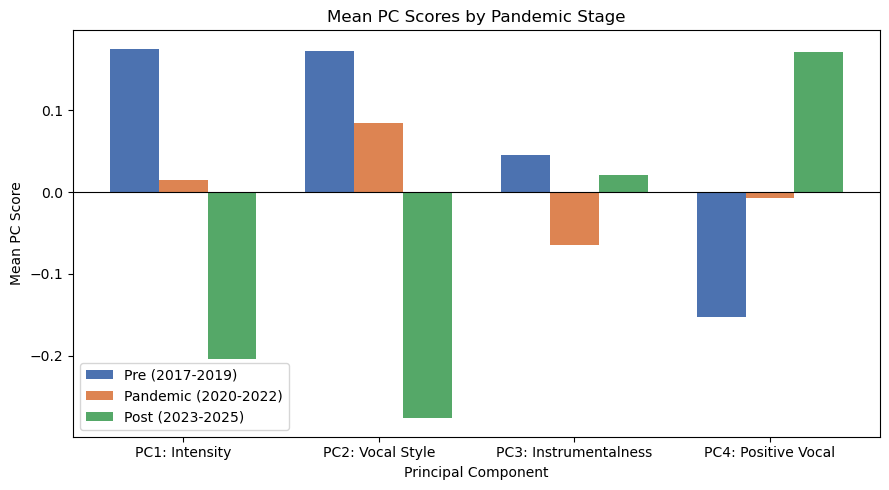

In [2]:
mean_pc = df.groupby('Stage')[pcs].mean().reindex(stage_order)
mean_pc.index = [stage_labels[s] for s in mean_pc.index]

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(pcs))
width = 0.25

for i, (stage, row) in enumerate(mean_pc.iterrows()):
    ax.bar(x + i * width, row[pcs], width, label=stage, color=colors[i])

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels([pc_labels[p] for p in pcs])
ax.set_xlabel('Principal Component')
ax.set_ylabel('Mean PC Score')
ax.set_title('Mean PC Scores by Pandemic Stage')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/fig1_mean_pc_by_stage.png', dpi=200)
plt.show()

## Figure 2: PC Score Trends Over Time (Annual)

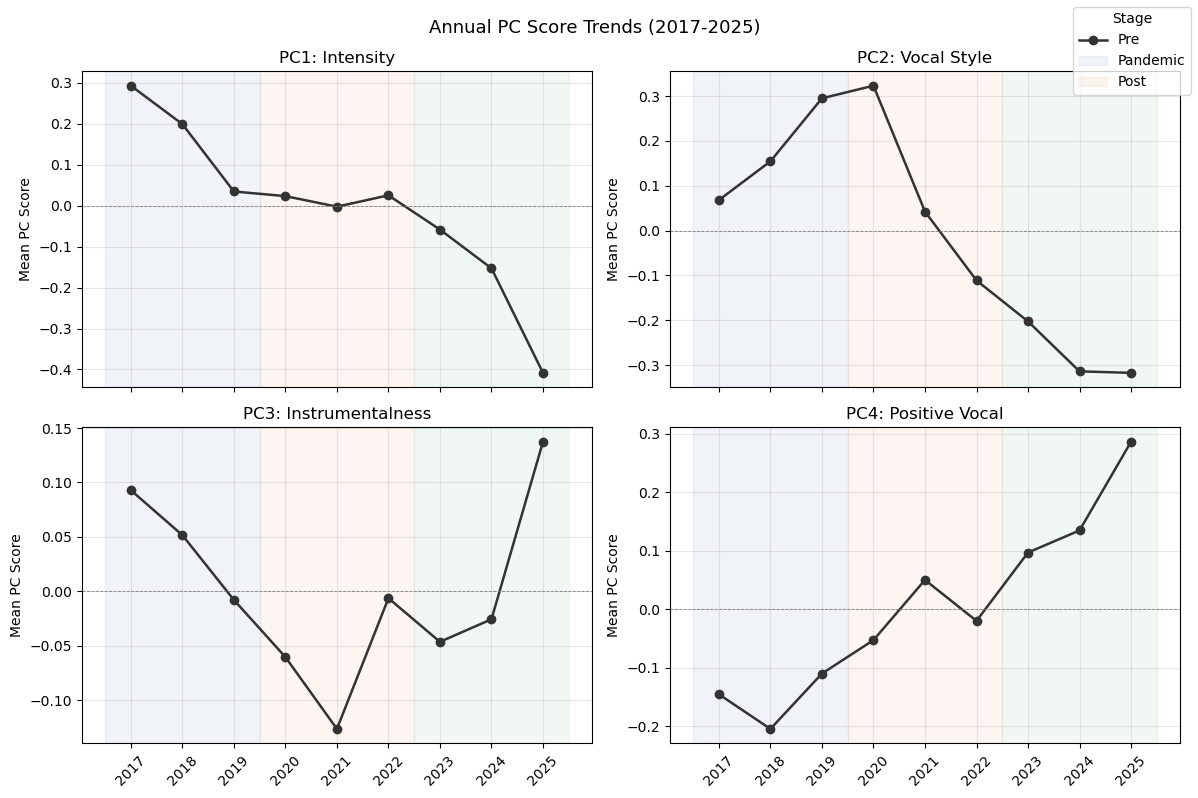

In [3]:
annual_pc = df.groupby('Year')[pcs].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
axes = axes.ravel()

stage_spans = [
    (2017, 2019, '#4C72B0', 0.08, 'Pre'),
    (2020, 2022, '#DD8452', 0.08, 'Pandemic'),
    (2023, 2025, '#55A868', 0.08, 'Post')
]

for i, pc in enumerate(pcs):
    ax = axes[i]
    ax.plot(annual_pc['Year'], annual_pc[pc], marker='o', color='#333333', linewidth=1.8)
    
    for start, end, color, alpha, label in stage_spans:
        ax.axvspan(start - 0.5, end + 0.5, alpha=alpha, color=color, label=label if i == 0 else '_')
    
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax.set_title(pc_labels[pc])
    ax.set_ylabel('Mean PC Score')
    ax.set_xticks(annual_pc['Year'])
    ax.set_xticklabels(annual_pc['Year'], rotation=45)
    ax.grid(alpha=0.3)

fig.legend(['Pre', 'Pandemic', 'Post'], loc='upper right', title='Stage')
fig.suptitle('Annual PC Score Trends (2017-2025)', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fig2_pc_trends_over_time.png', dpi=200)
plt.show()

## Figure 3: PC Score Distribution by Stage (Box Plot)

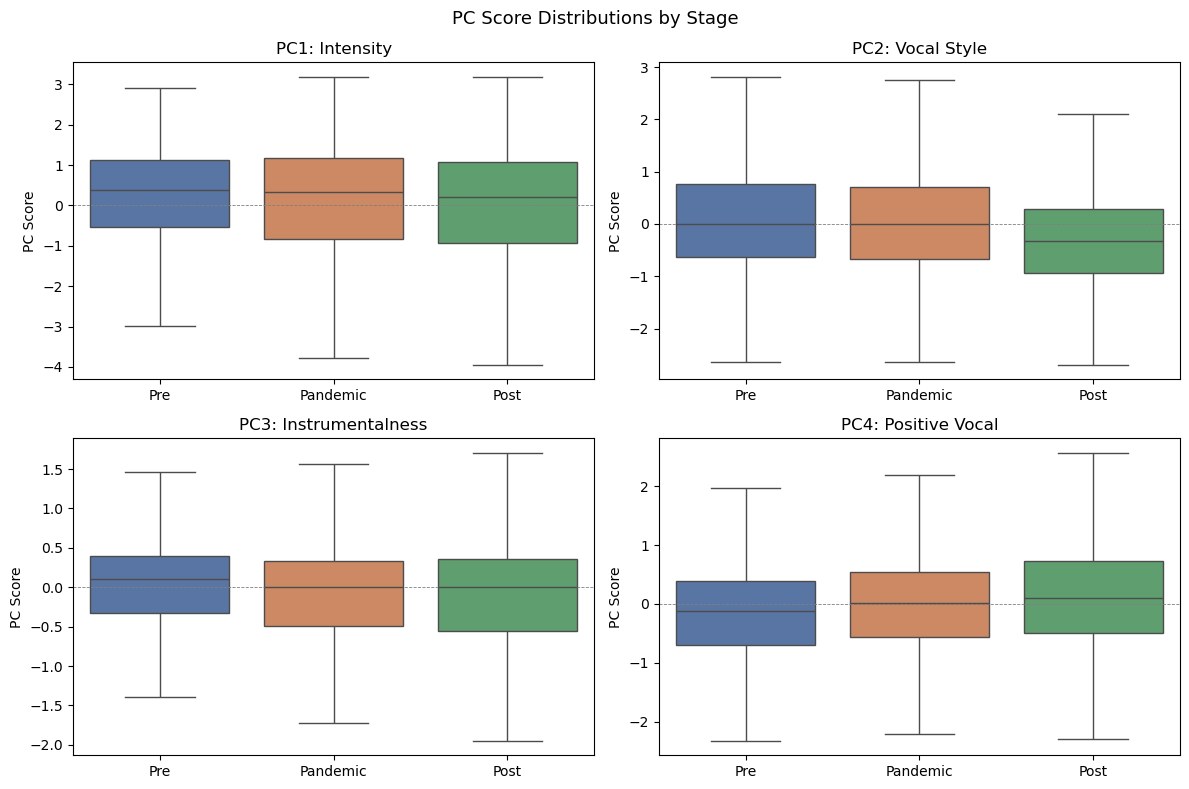

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

stage_palette = {
    'Pre (2017-2019)': '#4C72B0',
    'Pandemic (2020-2022)': '#DD8452',
    'Post (2023-2025)': '#55A868'
}

df_plot = df.copy()
df_plot['Stage_Label'] = df_plot['Stage'].map(stage_labels)

for i, pc in enumerate(pcs):
    ax = axes[i]
    sns.boxplot(
        data=df_plot,
        x='Stage_Label',
        y=pc,
        order=[stage_labels[s] for s in stage_order],
        hue='Stage_Label',
        palette=stage_palette,
        legend=False,
        ax=ax,
        showfliers=False
    )
    ax.set_title(pc_labels[pc])
    ax.set_xlabel('')
    ax.set_ylabel('PC Score')
    ax.set_xticks(range(3))
    ax.set_xticklabels(['Pre', 'Pandemic', 'Post'])
    ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')

fig.suptitle('PC Score Distributions by Stage', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/fig3_pc_distributions.png', dpi=200)
plt.show()

## Figure 4: Cluster Distribution by Stage

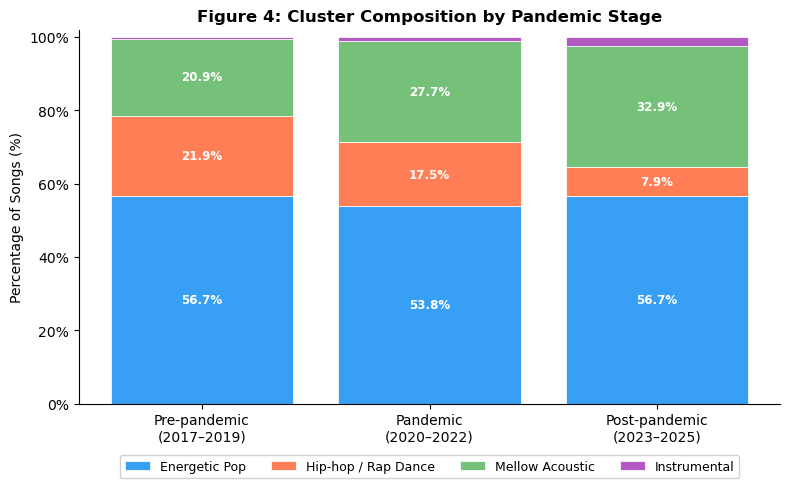

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

df_clust = pd.read_csv('../data/df_clustered.csv')

stage_order  = ['Stage 1 (2017-2019)', 'Stage 2 (2020-2022)', 'Stage 3 (2023-2025)']
stage_labels = ['Pre-pandemic\n(2017–2019)', 'Pandemic\n(2020–2022)', 'Post-pandemic\n(2023–2025)']

cluster_order  = [2, 0, 1, 3]
cluster_names  = {2: 'Energetic Pop', 0: 'Hip-hop / Rap Dance',
                  1: 'Mellow Acoustic', 3: 'Instrumental'}
cluster_colors = {2: '#2196F3', 0: '#FF7043', 1: '#66BB6A', 3: '#AB47BC'}

counts = (df_clust.groupby(['Stage', 'Cluster'])
          .size()
          .unstack(fill_value=0)
          .loc[stage_order, cluster_order])
props = counts.div(counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for cid in cluster_order:
    vals = props[cid].values
    ax.bar(x, vals, bottom=bottom,
           color=cluster_colors[cid], alpha=0.9,
           label=cluster_names[cid], edgecolor='white', linewidth=0.6)
    for j, (v, b) in enumerate(zip(vals, bottom)):
        if v >= 5:
            ax.text(j, b + v / 2, f'{v:.1f}%',
                    ha='center', va='center', fontsize=8.5,
                    color='white', fontweight='bold')
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels(stage_labels, fontsize=10)
ax.set_ylabel('Percentage of Songs (%)', fontsize=10)
ax.set_ylim(0, 102)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
ax.set_title('Figure 4: Cluster Composition by Pandemic Stage',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12),
          ncol=4, fontsize=9, framealpha=0.9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/fig4_cluster_distribution.png', dpi=150, bbox_inches='tight')
plt.show()